# Signatures of Quantum Chaos in Random Optical Networks

## Abstract
This project investigates the probability densities of possible outputs from Gaussian Boson Sampling (GBS), one of the main models used to demonstrate quantum computational advantage. We investigate the distributions produced by injecting squeezed states into randomly selected optical networks, and analyse the effects on this distribution when key variables such as the squeezing amplitude and the transmission coefficient are altered. These variations imitate different input state preparations as well as varying levels of environmental decoherence (photon loss) in the system. Given that GBS has recently proven highly useful as an analogue quantum device for solving problems in graph theory, drug discovery, and artificial intelligence, understanding its chaotic signatures and its robustness to noise is important. This project demonstrates the transition to a Porter-Thomas distribution, a fundamental signature of quantum chaos, and quantifies its degradation under loss using Total Variation Distance (TVD).

## Background
Gaussian Boson Sampling consists of injecting squeezed vacuum states into an optical network, as opposed to standard Boson Sampling which relies on single-photon Fock states that are experimentally difficult to generate. These input states propagate through $M$ modes in an optical network consisting of phase shifters and beam splitters. As they propagate, the states interfere in a highly entangled way such that the probability of specific output being detected corresponds to a matrix function called the Hafnian.
Calculating the Hafnian is in the $\sharp$P-hard complexity class, meaning it scales exponentially and becomes highly computationally expensive for larger matrices. It is important to note that GBS is not used to calculate specific Hafnians efficiently, estimating a single probability to high precision would require an exponential number of experimental samples. Instead, the quantum advantage comes from sampling from this complex distribution, something that classical computers cannot simulate efficiently. By measuring the output probabilities of multiple Haar-random optical networks and plotting their probability density, we observe the emergence of the Porter-Thomas distribution, a definitive signature of quantum chaos.
To explore the robust nature of this chaos, we altered two key parameters: the transmission coefficient ($\eta$), corresponding to photon loss/outside noise, and the initial squeezing value ($r$). For the former, we calculated the Total Variation Distance (TVD) to measure how far the lossy system deviates from the ideal chaotic regime. For the latter, we generated histograms to map the Porter-Thomas distribution under varying degrees of non-classical input strength. Mathematically, the squeezed vacuum states are created using the squeezing transformation $S$:$$S = \begin{pmatrix} \bigoplus_{j=1}^M \cosh(r_j) & \bigoplus_{j=1}^M \sinh(r_j)\\  \bigoplus_{j=1}^M \sinh(r_j) & \bigoplus_{j=1}^M \cosh(r_j) \end{pmatrix}$$ where $r_j$ is the corresponding squeezing parameter for the $j$-th mode.

The optical network is represented by $T$, a unitary matrix generated uniformly at random from the Haar measure. The final covariance matrix of the state after passing through the interferometer is given by:$$\sigma = \frac{1}{2}  \begin{pmatrix} T & 0 \\ 0 & T^{*} \end{pmatrix} S S^{\dagger} \begin{pmatrix} T^{\dagger} & 0 \\ 0 & T^t \end{pmatrix}$$

To accurately reflect realistic experimental conditions, we must model uniform photon loss, which inevitably degrades quantum correlations. Loss is represented by the transmission coefficient $\eta$, where $\eta = 1.0$ is a perfectly lossless system and $\eta < 1.0$ introduces vacuum noise. The degraded covariance matrix, $\sigma_{\text{loss}}$, shrinks toward the vacuum state $\mathbb{I}/2$ proportionally to the loss:$$\sigma_{\text{loss}} = \eta \sigma + (1 - \eta) \frac{\mathbb{I}}{2}$$
Similarly, the $B$-matrix scales linearly with transmission:$$B_{\text{loss}} = \eta B$$

To calculate the probability of a specific output measurement (e.g., threshold detection where we measure either zero or one photon per mode), we must map this covariance matrix to the Husimi Q-function representation. This is done by adding vacuum noise, yielding the Q-function covariance matrix $\sigma_Q = \sigma_{\text{loss}} + \mathbb{I}/2$. The probability $\Pr(\bar{n})$ of a specific collision-free output detection event is then given by: $$Pr(\bar{n}) = |\sigma_Q|^{-\frac{1}{2}} |Haf(B_s)|^2$$ 
Here, $B_s$ is the reduced matrix of $B$, which is defined as:$$B = T \left( \bigoplus_{j=1}^M \tanh r_j \right) T^t$$

The matrix $B$ is reduced to $B_s$ by isolating the rows and columns corresponding to the specific output modes where photons are detected. The Hafnian itself calculates the sum of all possible perfect matchings in a graph and is defined as:$$\text{Haf}(A) = \sum_{M \in \text{PMP}(n)} \prod_{(i,j) \in M} A_{i,j}$$where $\text{PMP}(n)$ stands for the set of perfect matching permutations of $n$.

## Results
### Graph A - The Porter-Thomas Distribution

Under the ideal lossless conditions ($\eta = 1.0$), with squeezing parameter of r=1, the simulation maps the output probabilities across 1000 random optical network configurations. The histogram outputted shows rapid exponential decay in probability density. The simulated data also aligned very closely to the theoretical Porter-Thomas distribution curve: $P(x) = (1/\mu) \exp(-x/\mu)$. This is physical proof that injecting continuous-variable states into Haar-random unitaries successfully generates the complex interference required to exhibit quantum chaos.

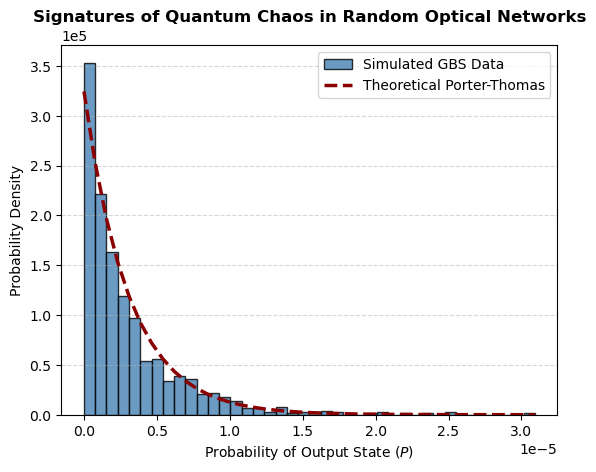

In [1]:
import numpy as np
from thewalrus import hafnian    
from scipy.stats import unitary_group
import matplotlib.pyplot as plt

#Creating the Formula using the GBS paper (shortcut for squeezed states)

def Gen_unitary_matrix(N):
    ''' Generates a random unitary matrix sampled uniformly from the Haar measure'''
    U_initial = unitary_group.rvs(dim=N)
    U_optic_net = U_initial.copy() 
    return U_optic_net

    
def squeezing(N, R):
    '''Creates the squeezing matrix'''
    S = np.zeros((2*N,2*N))
    R_cosh = np.cosh(R)
    R_cosh = np.append(R_cosh, R_cosh)
    R_sinh = np.sinh(R)
    S = np.diag(R_cosh)
    S[N:2*N, 0:N] = np.diag(R_sinh)
    S[0:N, N:2*N] = np.diag(R_sinh)
    return S

def Covariance(T, S, N):
    '''Creates the covariance matrix using optical netwrok's unitary matrix T and squeezing matrix, S'''
    T_star = np.conj(T)
    T_trans = T.transpose()
    T_dagger = np.conj(T_trans)
    S_dagger = np.conj(S.transpose())
    matr_1 = np.zeros((2*N, 2*N), dtype='complex')
    matr_1[0:N, 0:N] = T
    matr_1[N:2*N, N:2*N] = T_star
    matr_2 = np.zeros((2*N, 2*N), dtype='complex')
    matr_2[0:N, 0:N] = T_dagger
    matr_2[N:2*N, N:2*N] = T_trans
    sigma = 1/2*matr_1@S@S_dagger@matr_2
    return sigma

def B_matr(T, R, N):
    '''Generates the B matrix '''
    R_tanh = np.tanh(R)
    B = T@np.diag(R_tanh)@T.transpose()
    return B

def B_s_matrix(B, det_modes):
    '''Generates the matrix required ot calculate the Hafnian from'''
    mesh = np.ix_(det_modes, det_modes)
    B_s = B[mesh]
    return B_s


def probability(sigma, B_s):
    '''Calculates the probability'''
    prob = np.real(np.linalg.det(sigma)**(-1/2))*np.abs(hafnian(B_s))**2
    return prob

sample_size = 1000
N = 4
M = N**2 #number of modes
R = [1]*M
det_modes = np.arange(N)
total_probabilities = []
for i in range(sample_size):

    T = Gen_unitary_matrix(M)
    S = squeezing(M, R)
    sigma = Covariance(T, S, M)
    B = B_matr(T, R, M)
    B_s = B_s_matrix(B, det_modes)
    sigma_Q = sigma + np.eye(2*M)/2
    prob = probability(sigma_Q, B_s)
    total_probabilities.append(prob)

fig, ax = plt.subplots(1,1)

mean_prob = np.mean(total_probabilities)

n, bins, patches = ax.hist(total_probabilities, bins=40, density=True, color='steelblue', edgecolor='black', alpha=0.8, label='Simulated GBS Data')

theoretical_y = (1 / mean_prob) * np.exp(-bins / mean_prob)
ax.plot(bins, theoretical_y, color='darkred', linewidth=2.5, linestyle='--', label='Theoretical Porter-Thomas')

ax.set_title("Signatures of Quantum Chaos in Random Optical Networks", fontweight='bold')
ax.set_xlabel("Probability of Output State ($P$)")
ax.set_ylabel("Probability Density")
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

ax.legend()
plt.show()

### Graph B - TVD and Photon Loss

This graph shows the system's vulnerability to environmental noise by plotting the Total Variational Distance against the transmission coefficient $\eta$. As the transmission is changed from 1.0 (lossless) down to 0.1 (heavy loss), the TVD sharply increases. This increase signifies that the output probability distribution is deviating significantly from the ideal Porter-Thomas curve. The heavy photon loss replaces non-classical correlations with vacuum noise, destroying the multiphoton interference and causing the system to lose its chaotic quantum signatures.

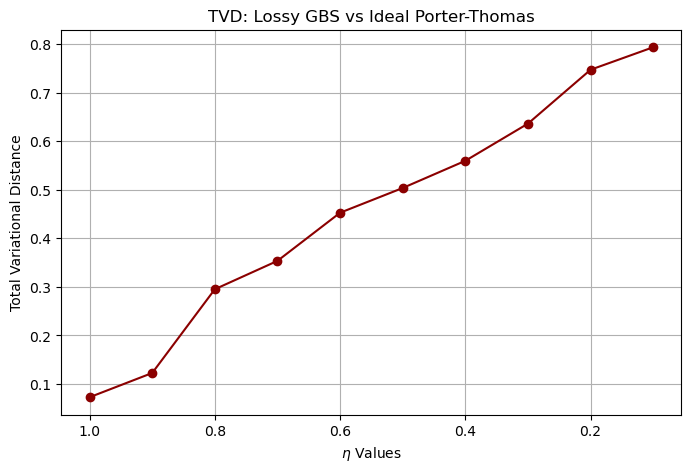

In [2]:
sample_size = 1000
N = 4
M = N**2 
R = [1]*M
det_modes = np.arange(N)
total_eta_probabilities = []

eta_vals = np.linspace(0.1, 1.0, 10)
eta_vals = np.flip(eta_vals) 
tvd_vals = []
def p(x, total_probabilities):
    '''Returns the values for theoretical Porter-Thomas '''
    mean_prob = np.mean(total_probabilities)
    p = (1/mean_prob)*np.e**(-x/mean_prob)
    return p

for eta in eta_vals:
    total_probabilities = []
    for i in range(sample_size):
        T = Gen_unitary_matrix(M)
        S = squeezing(M, R)
        sigma = Covariance(T, S, M)
        B = B_matr(T, R, M)
        
        sigma_loss = eta * sigma + (1 - eta) * (np.eye(2*M) / 2)
        B_loss = eta * B
        
        B_s = B_s_matrix(B_loss, det_modes)
        sigma_Q = sigma_loss + np.eye(2*M)/2
        prob = probability(sigma_Q, B_s)
        total_probabilities.append(prob)
        
    Q = np.array(total_probabilities)

    if eta == 1.0:
        ideal_mean = np.mean(Q)
        _, fixed_bins = np.histogram(Q, bins=40)
        bin_widths = np.diff(fixed_bins)
        bin_centres = (fixed_bins[:-1] + fixed_bins[1:]) / 2
        P = p(bin_centres, ideal_mean)

    hist, _ = np.histogram(Q, bins=fixed_bins, density=True)
    tvd = 0.5 * np.sum(np.abs(P - hist) * bin_widths)
    
    total_eta_probabilities.append(Q)
    tvd_vals.append(tvd)


fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(eta_vals, tvd_vals, marker='o', color='darkred')
ax.grid(True)
ax.set_xlabel(r'$\eta$ Values')
ax.set_ylabel('Total Variational Distance')
ax.set_title("TVD: Lossy GBS vs Ideal Porter-Thomas")
plt.gca().invert_xaxis() 
plt.show()

### Graph C - Squeezing Parameter Variation

To test the effect of the input state on the chaotic outputs, the ideal simulation was run at three different squeezing amplitudes: $r = 0.2$, $r = 1$, and $r = 2$. As the squeezing parameter increases, the average number of photons injected into the system grows substantially. This higher photon number dramatically increases the size of the output state space, causing the mean probability $\mu$ of observing any individual output state to shrink. Consequently, we observe different scale changes across the three subplots, for higher values of $r$, the probability densities increases significantly near zero, and the exponential decrease of the probabilities along the x-axis becomes much more rapid. Despite these drastic shifts in scale, the fundamental shape of the distributions remains unchanged, with all three density histograms tightly hugging their respective theoretical Porter-Thomas curves. 

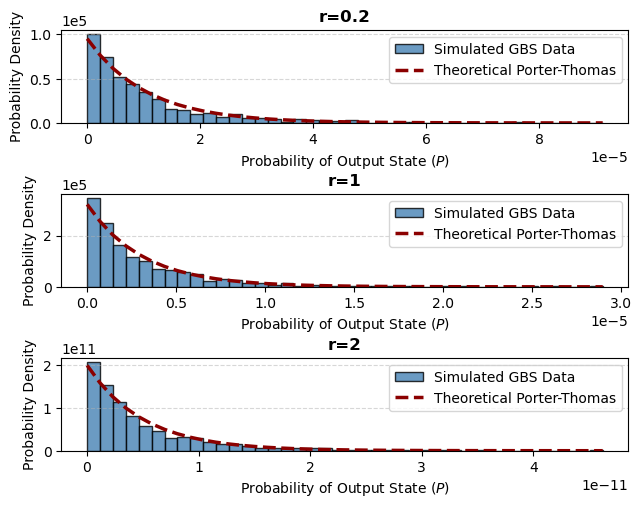

In [3]:
sample_size = 1000
N = 4
M = N**2
det_modes = np.arange(N)
total_r_probabilities = []
r_val = [0.2,1,2]

for r in r_val:
    R = [r]*M
    total_probabilities = []
    for i in range(sample_size):
    
        T = Gen_unitary_matrix(M)
        S = squeezing(M, R)
        sigma = Covariance(T, S, M)
        B = B_matr(T, R, M)
        B_s = B_s_matrix(B, det_modes)
        sigma_Q = sigma + np.eye(2*M)/2
        prob = probability(sigma_Q, B_s)
        total_probabilities.append(prob)
    total_r_probabilities.append(total_probabilities)
fig, ax = plt.subplots(3,1)
fig.tight_layout(h_pad = 3.0)
for i in range(len(r_val)):
    mean_prob = np.mean(total_r_probabilities[i])
    
    n, bins, patches = ax[i].hist(total_r_probabilities[i], bins=40, density=True, color='steelblue', edgecolor='black', alpha=0.8, label='Simulated GBS Data')
    
    theoretical_y = (1 / mean_prob) * np.exp(-bins / mean_prob)
    ax[i].plot(bins, theoretical_y, color='darkred', linewidth=2.5, linestyle='--', label='Theoretical Porter-Thomas')
    
    ax[i].set_title(('r='+str(r_val[i])), fontweight='bold')
    ax[i].set_xlabel("Probability of Output State ($P$)")
    ax[i].set_ylabel("Probability Density")
    ax[i].grid(axis='y', linestyle='--', alpha=0.5)
    ax[i].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax[i].legend()

plt.show()

## Conclusion
Through this simulation of Gaussian Boson Sampling across Haar-random linear optical networks, we have successfully verified that multiphoton interference yields a Porter-Thomas output distribution, a key hallmark of quantum chaos. By evaluating the system under varying parameters, we observed that the Porter-Thomas distribution is fundamentally robust to changes in the input squeezing magnitude. However, our computation of the Total Variational Distance under simulated photon loss revealed that environmental decoherence washes out these signatures quickly. This balance between input non-classicality and environmental loss is critical for the engineering and scaling of practical GBS devices.